In [1]:
!git clone https://bitbucket.org/jadslim/german-traffic-signs

Cloning into 'german-traffic-signs'...
Receiving objects: 100% (6/6), 117.80 MiB | 15.89 MiB/s, done.
Updating files: 100% (4/4), done.


In [2]:
!ls german-traffic-signs

signnames.csv  test.p  train.p	valid.p


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, Input
from keras.layers import Flatten, Dropout
from keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D
import random
import pickle
import pandas as pd
import cv2
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [4]:
from keras.callbacks import LearningRateScheduler, ModelCheckpoint

%matplotlib inline
np.random.seed(0)

In [5]:
#: Implement load the data here.
with open('german-traffic-signs/train.p', 'rb') as f:
    train_data = pickle.load(f)
with open('german-traffic-signs/valid.p', 'rb') as f:
    val_data = pickle.load(f)
#: Load test data
with open('german-traffic-signs/test.p', 'rb') as f:
    test_data = pickle.load(f)

In [6]:
# Split out features and labels
X_train, y_train = train_data['features'], train_data['labels']
X_val, y_val = val_data['features'], val_data['labels']
X_test, y_test = test_data['features'], test_data['labels']

In [7]:
#already 4 dimensional
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(34799, 32, 32, 3)
(12630, 32, 32, 3)
(4410, 32, 32, 3)


In [8]:
# STOP: Do not change the tests below. Your implementation should pass these tests.
assert(X_train.shape[0] == y_train.shape[0]), "The number of images is not equal to the number of labels."
assert(X_train.shape[1:] == (32,32,3)), "The dimensions of the images are not 32 x 32 x 3."
assert(X_val.shape[0] == y_val.shape[0]), "The number of images is not equal to the number of labels."
assert(X_val.shape[1:] == (32,32,3)), "The dimensions of the images are not 32 x 32 x 3."
assert(X_test.shape[0] == y_test.shape[0]), "The number of images is not equal to the number of labels."
assert(X_test.shape[1:] == (32,32,3)), "The dimensions of the images are not 32 x 32 x 3."

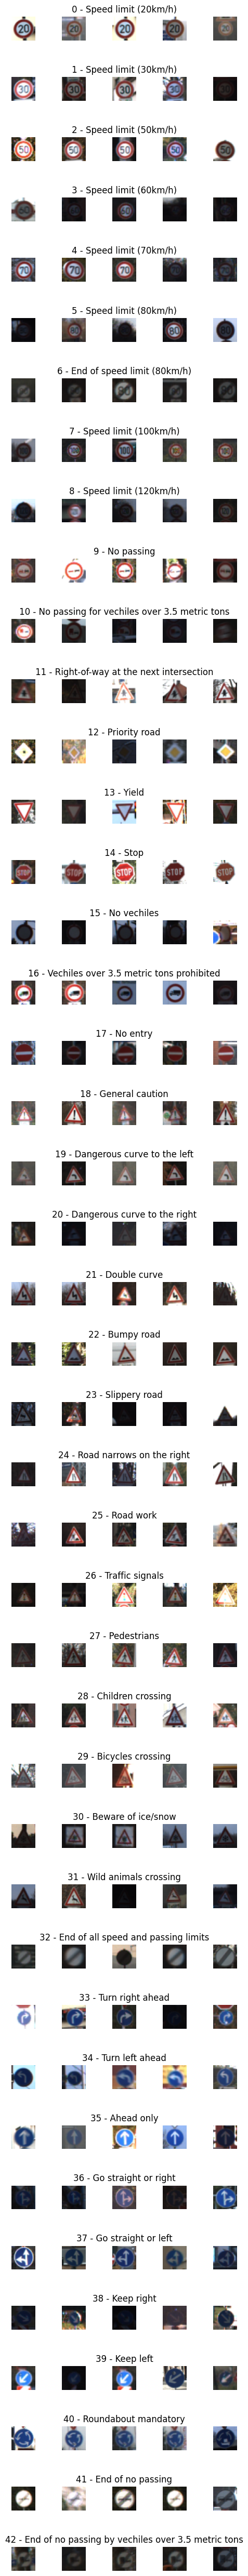

In [9]:
data = pd.read_csv('german-traffic-signs/signnames.csv')

num_of_samples = []

cols = 5
num_classes = 43

fig, axs = plt.subplots(
    nrows=num_classes,
    ncols=cols,
    figsize=(5, 50)
)
fig.tight_layout()

for i in range(cols):
    for j, row in data.iterrows():
        x_selected = X_train[y_train == j]

        axs[j][i].imshow(
            x_selected[random.randint(0, len(x_selected) - 1), :, :],
            cmap=plt.get_cmap('gray')
        )
        axs[j][i].axis("off")

        if i == 2:
            axs[j][i].set_title(
                str(j) + " - " + row["SignName"]
            )
            num_of_samples.append(len(x_selected))

[180, 1980, 2010, 1260, 1770, 1650, 360, 1290, 1260, 1320, 1800, 1170, 1890, 1920, 690, 540, 360, 990, 1080, 180, 300, 270, 330, 450, 240, 1350, 540, 210, 480, 240, 390, 690, 210, 599, 360, 1080, 330, 180, 1860, 270, 300, 210, 210]


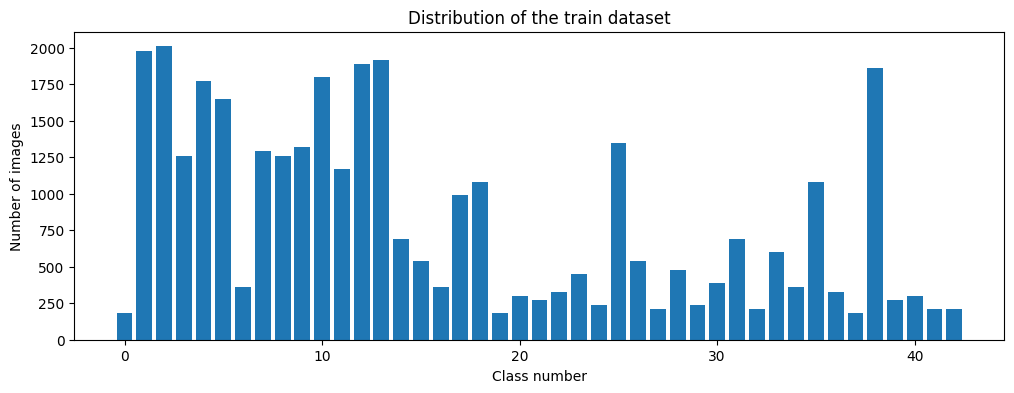

In [10]:
print(num_of_samples)

plt.figure(figsize=(12, 4))
plt.bar(range(0, num_classes), num_of_samples)
plt.title("Distribution of the train dataset")
plt.xlabel("Class number")
plt.ylabel("Number of images")
plt.show()

(32, 32, 3)
36


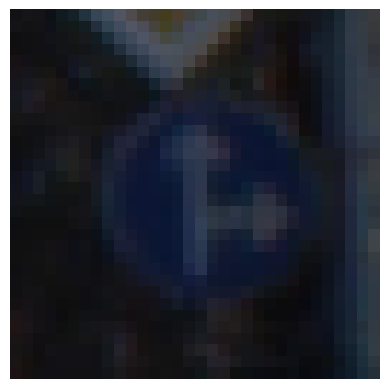

In [11]:
import cv2

plt.imshow(X_train[1000])
plt.axis("off")
print(X_train[1000].shape)
print(y_train[1000])

(32, 32)


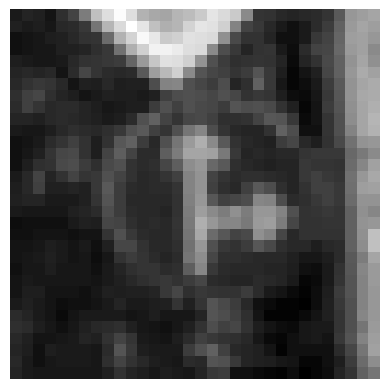

In [12]:
# preprocess of image to grascale
def grayscale(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img
img = grayscale(X_train[1000])
plt.imshow(img, cmap='gray')
plt.axis("off")
print(img.shape)

(32, 32)


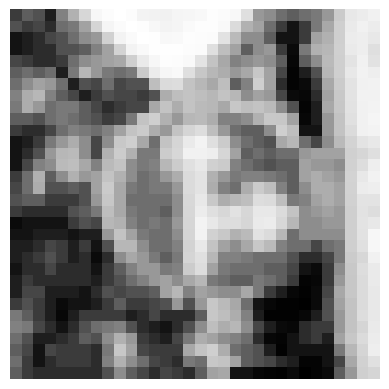

In [13]:
#preprocess image with histogram equalization
def equalize(img):
    img = cv2.equalizeHist(img)
    return img
img = equalize(img)
plt.imshow(img, cmap='gray')
plt.axis("off")
print(img.shape)

In [14]:
def preprocess(img):
    img = grayscale(img)
    img = equalize(img)
    img = img/255
    return img

X_train = np.array(list(map(preprocess, X_train)))
X_test = np.array(list(map(preprocess, X_test)))
X_val = np.array(list(map(preprocess, X_val)))

(34799, 32, 32)


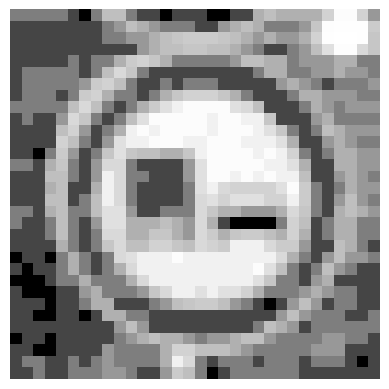

In [15]:
plt.imshow(X_train[random.randint(0, len(X_train) - 1)], cmap='gray')
plt.axis('off')
print(X_train.shape)

In [16]:
# Add a channel dimension to grayscale images: (H, W) -> (H, W, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]
X_val   = X_val[..., np.newaxis]

(15, 32, 32, 1)


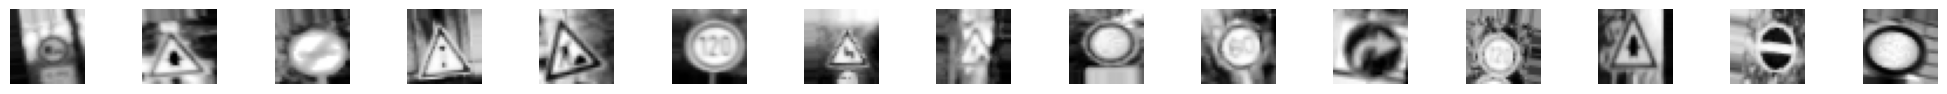

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(width_shift_range=0.1,
                            height_shift_range=0.1,
                            zoom_range=0.2,
                            shear_range=0.1,
                            rotation_range=10.)

datagen.fit(X_train)
# for X_batch, y_batch in

batches = datagen.flow(X_train, y_train, batch_size = 15)
X_batch, y_batch = next(batches)

fig, axs = plt.subplots(1, 15, figsize=(20, 5))
fig.tight_layout()

for i in range(15):
    axs[i].imshow(X_batch[i].squeeze(), cmap='gray')
    axs[i].axis("off")

print(X_batch.shape)

In [18]:
# one-hot the label
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)
y_val = to_categorical(y_val, 43)
# create model

def modified_model():
  model = Sequential()
  model.add(Input(shape=(32, 32, 1)))
  model.add(Conv2D(60, (5, 5), activation='relu'))
  model.add(Conv2D(60, (5, 5), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(30, (3, 3), activation='relu'))
  model.add(Conv2D(30, (3, 3), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Flatten())
  model.add(Dense(500, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(43, activation='softmax'))

  model.compile(Adam(learning_rate= 0.001), loss='categorical_crossentropy', metrics=['accuracy'])
  return model
model = modified_model()
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 60)     │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 60)     │        90,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 30)     │        16,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 30)       │         8,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 30)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       240,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        21,543 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 378,023 (1.44 MB)

 Trainable params: 378,023 (1.44 MB)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=50),
                            # steps_per_epoch=len(X_train) // 50,
                            epochs=10,
                            validation_data=(X_val, y_val), shuffle = 1)

Epoch 1/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.4822 - loss: 1.8189 - val_accuracy: 0.9206 - val_loss: 0.2971
Epoch 2/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.8217 - loss: 0.5802 - val_accuracy: 0.9549 - val_loss: 0.1381
Epoch 3/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.8954 - loss: 0.3431 - val_accuracy: 0.9712 - val_loss: 0.0958
Epoch 4/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9207 - loss: 0.2593 - val_accuracy: 0.9814 - val_loss: 0.0617
Epoch 5/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9387 - loss: 0.1976 - val_accuracy: 0.9841 - val_loss: 0.0568
Epoch 6/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9475 - loss: 0.1700 - val_accuracy: 0.9868 - val_loss: 0.0466
Epoch 7/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9535 - loss: 0.1500 - val_accuracy: 0.9810 - val_loss: 0.0645
Epoch 8/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.9595 - loss: 0.1310 - 

Test score: 0.12755873799324036
Test accuracy: 0.9643705487251282


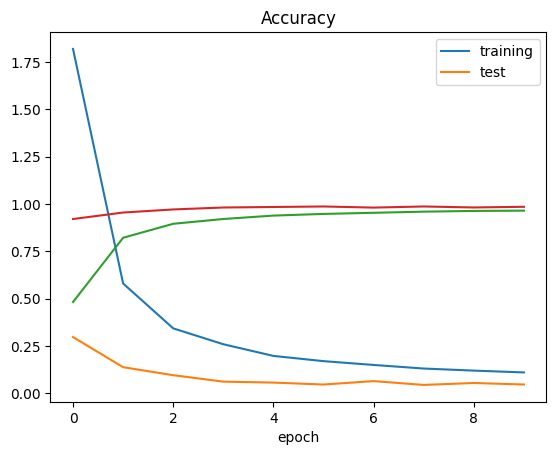

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('epoch')

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training','test'])
plt.title('Accuracy')
plt.xlabel('epoch')

#Evaluate model on test data
score = model.evaluate(X_test, y_test, verbose=0)
print('Test score:', score[0])
print('Test accuracy:', score[1])

(np.float64(-0.5), np.float64(1299.5), np.float64(945.5), np.float64(-0.5))

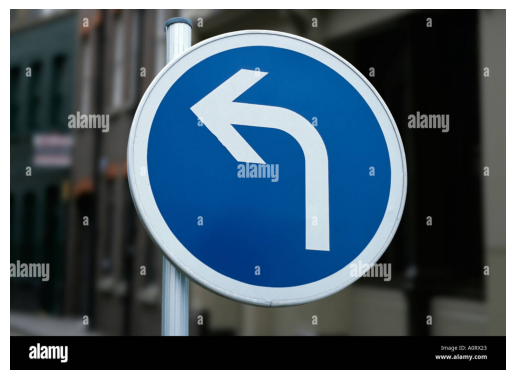

In [21]:
#predict internet number
import requests
from PIL import Image
url = 'https://c8.alamy.com/comp/A0RX23/cars-and-automobiles-must-turn-left-ahead-sign-A0RX23.jpg'
r = requests.get(url, stream=True)
img = Image.open(r.raw)
plt.imshow(img, cmap='gray')
plt.axis('off')

(32, 32)


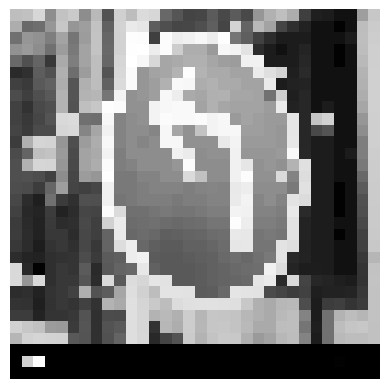

In [22]:
img = np.asarray(img)
img = cv2.resize(img, (32, 32))
img = preprocess(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
print(img.shape)

In [23]:
img = img.reshape(1, 32, 32, 1)
print("predicted sign: "+ str(model.predict(img)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step
predicted sign: [[2.6015448e-10 4.7908547e-06 1.3006907e-05 2.4719122e-05 7.9931354e-08
  2.2089253e-03 4.8030319e-10 2.0677820e-05 3.4997465e-06 1.8002125e-07
  4.9662421e-04 4.9323073e-05 4.1342494e-03 7.1475595e-05 4.0427447e-05
  2.9218229e-06 1.0537022e-07 4.6357723e-05 2.0292971e-08 1.8869393e-09
  4.7511270e-09 1.4223081e-06 4.0560270e-08 3.0789180e-09 5.4494870e-10
  1.3630996e-08 2.6034744e-11 3.9829907e-11 6.7439472e-09 6.9793458e-08
  9.9745250e-07 1.9439256e-06 5.1494701e-11 1.1291918e-08 7.7641326e-01
  1.2036033e-05 5.4440857e-06 1.5842625e-09 2.1640731e-01 1.4533547e-09
  3.8853752e-05 4.5829167e-11 1.2743409e-06]]
